# Calculating the design matrix
- Map response as a regressor
- Then split it up based on valence and volatility
- See how they are correlated amongst each other

In [41]:
import utils

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import math
import os
from nilearn.glm.first_level import make_first_level_design_matrix, check_design_matrix
from nilearn.plotting import plot_design_matrix, plot_design_matrix_correlation

plt.rcParams.update(plt.rcParamsDefault)
#pd.set_option('display.max_rows', None)

In [42]:
# Make output folder
output_dir = os.path.join('..','plots','fMRI','design_matrices')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [43]:
# To load the trigger files
def find_trigger_file(pattern: str, folder: str = '.') -> pd.DataFrame:
    folder = Path(folder)
    matches = list(folder.glob(pattern))

    if len(matches) == 0:
        raise FileNotFoundError(f"No files matching '{pattern}' in {folder}")
    if len(matches) > 1:
        raise ValueError(f"Multiple files match '{pattern}': {matches}")

    return pd.read_csv(matches[0], delimiter=';')

In [44]:
# Preparation
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers
raw_output_path = '/Volumes/project/3025011.02/raw/'
unique_subject_ids = [52]
unique_sessions = [2]

# Now create a boxcar for every single trial
boxcar_duration = 1.8

# Load and combine the datasets
combined_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions)

print(combined_dataframe)

    subject_id     session subjectively_correct_one_back subjectively_correct  \
0      sub-052  session-02                           NaN                 Late   
1      sub-052  session-02                          Late                 True   
2      sub-052  session-02                          True                False   
3      sub-052  session-02                         False                 True   
4      sub-052  session-02                          True                 True   
..         ...         ...                           ...                  ...   
447    sub-052  session-02                          True                False   
448    sub-052  session-02                         False                False   
449    sub-052  session-02                         False                False   
450    sub-052  session-02                         False                False   
451    sub-052  session-02                         False                False   

     same_response_as_one_b

/Volumes/kenvdzee/Documents/phd_1_analysis/utils/import_functions.py:633: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe['objectively_correct_boolean'] = dataframe['objectively_correct'].replace(mapping)
/Volumes/kenvdzee/Documents/phd_1_analysis/utils/import_functions.py:635: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe['subjectively_correct_boolean'] = dataframe['subjectively_correct'].replace(mapping)
/Volumes/kenvdzee/Documents/phd_1_analysis/utils/import_functions.py:675: FutureWarning: Downcasting behavio

Creating event file for subject 52 and session 2
     emotional_cue_time  response_time
0             38.511245      38.993138
1             42.248241      42.801396
0             45.599828      46.027251
1             49.369697      49.909782
2             53.910784      54.351997
..                  ...            ...
219         1973.327465    1973.878715
220         1977.599911    1977.995277
221         1982.392896    1982.995749
220         1987.001779    1987.395271
221         2001.304279    2002.037879

[442 rows x 2 columns]
    valence   congruency volatility congruency-volatility  duration
0     happy  incongruent   volatile  incongruent-volatile       1.8
1     happy  incongruent   volatile  incongruent-volatile       1.8
0     angry  incongruent   volatile  incongruent-volatile       1.8
1     angry  incongruent   volatile  incongruent-volatile       1.8
2     happy  incongruent   volatile  incongruent-volatile       1.8
..      ...          ...        ...                

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_11325/2782001630.py:69: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_11325/2782001630.py:79: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrix, ax=ax)


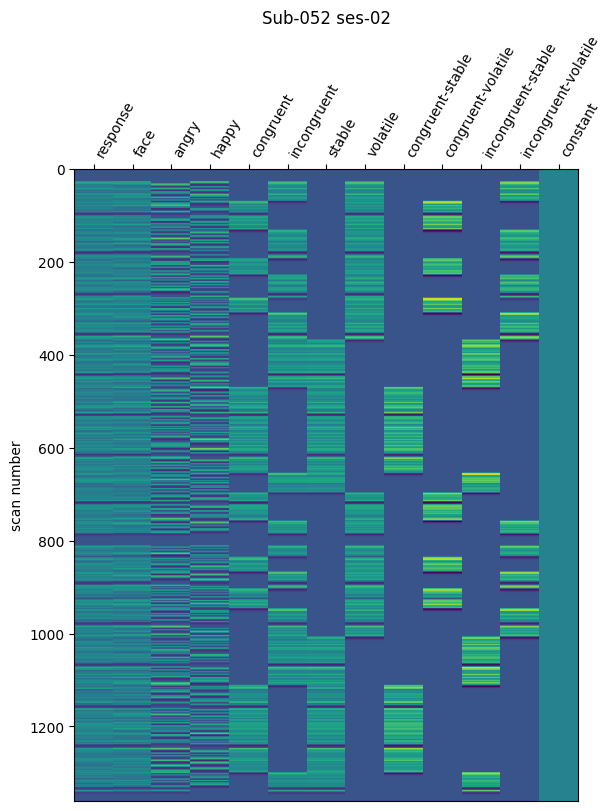

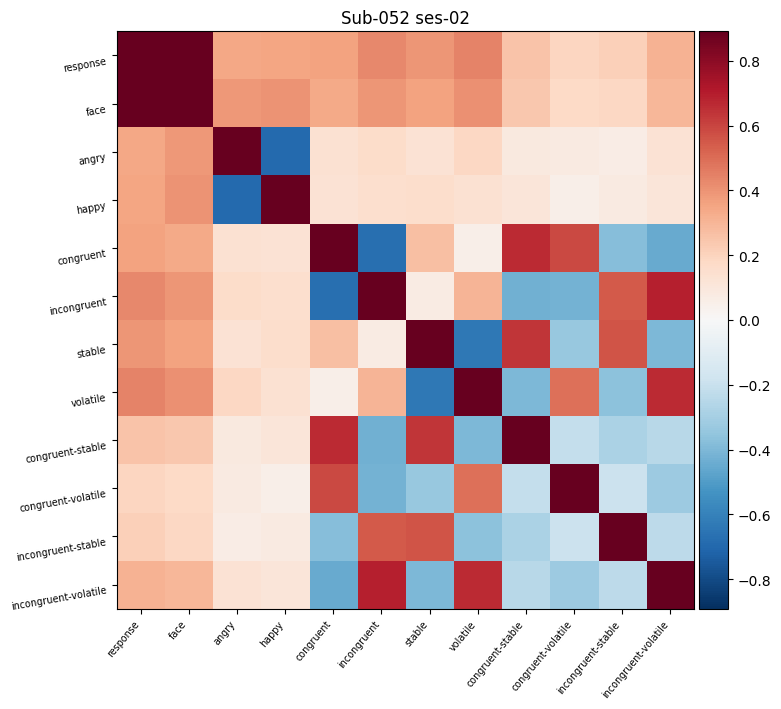

In [45]:
for subject_id in unique_subject_ids:
    for session in unique_sessions:
        # Set subject raw folder for later use:
        subject_raw_folder = f'/Volumes/project/3025011.02/raw/sub-{subject_id:03}/ses-mri{session:02}'

        print(f'Creating event file for subject {subject_id} and session {session}')
        dataframe = combined_dataframe[combined_dataframe['subject_id'] == f'sub-{subject_id:03}']
        dataframe = dataframe[dataframe['session'] == f'session-{session:02}']

        # Columns for sanity checks
        dataframe['contains_response'] = np.where(dataframe['response'].notna(), 'response', '')
        dataframe['contains_face'] = np.where(dataframe['valence'].notna(), 'face', '')

        # Determine when the scan for the first volume starts
        trigger_signals = find_trigger_file(f'trigger_signals_sub-{subject_id:03}_session-{session:02}*.csv', f'{subject_raw_folder}/beh')
        first_volume_start = trigger_signals.loc[trigger_signals['trigger'] == 1, 'trigger_time'].item()
        # Note down when each trial and each response starts
        dataframe['emotional_cue_time'] = dataframe['emotional_cue_time'] - first_volume_start
        dataframe['response_time'] = dataframe['response_time'] - first_volume_start
        print(dataframe[['emotional_cue_time', 'response_time']])

        # Combine variables
        dataframe['congruency-volatility'] = dataframe['congruency'] + '-' + dataframe['volatility']
        dataframe['onset'] = dataframe['emotional_cue_time']
        # Create a boxcar
        dataframe['duration'] = boxcar_duration
        print(dataframe[['valence','congruency','volatility','congruency-volatility','duration']])

        # Restructure into a time-series
        restructured_rows = []
        for _, row in dataframe.iterrows():
            restructured_rows.append({'trial_type': row['valence'], 'onset': row['onset'], 'duration': 0.1})
            restructured_rows.append({'trial_type': row['contains_face'], 'onset': row['onset'], 'duration': 0.1})
            restructured_rows.append({'trial_type': row['contains_response'], 'onset': row['response_time'], 'duration': 0.2}) # This is obviously a very rough estimate, adjust before final analysis
            restructured_rows.append({'trial_type': row['congruency'], 'onset': row['onset'], 'duration': row['duration']})
            restructured_rows.append({'trial_type': row['volatility'], 'onset': row['onset'], 'duration': row['duration']})
            restructured_rows.append({'trial_type': row['congruency-volatility'], 'onset': row['onset'], 'duration': row['duration']})

        # Convert to dataframe
        data_design_matrix = pd.DataFrame(restructured_rows)
        print(data_design_matrix)

        # Now create the design matrix and save it
        events = pd.DataFrame(
            {"trial_type": data_design_matrix['trial_type'], "onset": data_design_matrix['onset'], "duration": data_design_matrix['duration']}
        )
        print(events)
        events.to_csv(os.path.join(f'/Volumes/project/3025011.02/bids/sub-{subject_id:03}/ses-mri{session:02}/func/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_events.tsv'), sep='\t')

        # Scans timing
        # This method takes the actual triggers instead of assuming that the TR = 1.5 and that no scans are missed
        n_volumes = len(trigger_signals)
        volume_timepoints = trigger_signals['trigger_time'] - first_volume_start
        volume_timepoints = volume_timepoints.tolist()
        print(f'number of volumes: {n_volumes}')
        print(volume_timepoints)

        # Repetition time
        tr = 1.5
        # Look up number of volumes (since it's multi-echo, we need to divide by 3)
        raw_bold_folder = Path(f'{subject_raw_folder}/006-TaskAARL')
        # Count .IMA files (imperfect method !!!) let's change this to the trigger signals
        ima_files = list(raw_bold_folder.glob('*.IMA'))
        n_volumes = len(ima_files) / 3
        volume_timepoints = np.arange(0, n_volumes) * tr
        print(f'number of volumes: {n_volumes}')
        print(volume_timepoints)

        # fit the hemodynamic response function to the event file
        design_matrix = make_first_level_design_matrix(
            volume_timepoints,
            data_design_matrix
        )

        # Explicitly reorder columns
        design_matrix = design_matrix[['response', 'face', 'angry', 'happy', 'congruent', 'incongruent', 'stable', 'volatile', 'congruent-stable', 'congruent-volatile', 'incongruent-stable', 'incongruent-volatile', 'constant']]

        # Plot said matrix and save it
        fig, ax = plt.subplots(figsize=(6, 8), constrained_layout=True)
        plot_design_matrix(design_matrix, ax=ax)
        ax.set_title(f'Sub-{subject_id:03} ses-{session:02}')
        plt.savefig(os.path.join(output_dir, f'design_matrix_sub-{subject_id:03}_ses-mri{session:02}.pdf'))

        # Now also plot the correlation matrix and save it
        fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
        plot_design_matrix_correlation(design_matrix, axes=ax)
        ax.set_title(f'Sub-{subject_id:03} ses-{session:02}')
        plt.savefig(os.path.join(output_dir, f'regression_correlation_matrix_sub-{subject_id:03}_ses-mri{session:02}.pdf'))
        plt.show()
        # And save a CSV version of it
        correlation_matrix = design_matrix.corr()
        correlation_matrix.round(3).to_csv(os.path.join(output_dir, f'regression_correlation_matrix_sub-{subject_id:03}_ses-mri{session:02}.csv'), sep=';')